# LRA per-gene GC content

CheckM2's `quality_report.tsv` records GC to **2 decimals** — fine for sanity-checking the genome was Klebsiella but no help for separating sub-species or contamination signatures. Prodigal, which CheckM2 runs under the hood, writes per-protein `gc_cont=` to **3 decimals** in its `.faa` headers. This notebook works off that finer-grained data, sourced through `parse_protein_gc.py`.

Two TSV inputs, both produced on HPC by `parse_protein_gc.py`:

| TSV                              | Rows                                        | Per-row contents                                                   |
| -------------------------------- | ------------------------------------------- | ------------------------------------------------------------------ |
| `lra_per_gene_gc.tsv`            | one per `scoring_accession` (5,557)         | `n_proteins`, `mean_protein_gc`, `weighted_mean_protein_gc`, `median_protein_gc`, `std_protein_gc`, `min/max_protein_gc`, `total_dna_length` |
| `lra_per_protein_gc_sample.tsv`  | random 100 proteins per genome (~555,700)   | `gene_id`, `dna_length`, `gc_cont`                                |

Tier scheme matches `lra_quality_cutoffs.ipynb`: **GCF (blue)** vs **GCA (red)**.

Outputs of interest:

1. Per-protein GC distribution across the full cohort, GCF vs GCA.
2. Per-genome `weighted_mean_protein_gc` distribution (3-decimal replacement for CheckM2's `GC_Content`).
3. CheckM2 `GC_Content` (2-dec) vs the weighted-mean (3-dec) — does the higher-precision number reveal anything CheckM2 hid?
4. Per-genome GC heterogeneity (`std_protein_gc`) — outlier genomes are candidates for contamination or chimeric assembly.

## 1 · Load inputs

Three TSVs, HPC-first auto-detect:

- `lra_discovery.tsv` — for tier assignment + the existing CheckM2 columns.
- `lra_per_gene_gc.tsv` — per-genome aggregates.
- `lra_per_protein_gc_sample.tsv` — random per-protein sample (for histograms).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _first_existing(candidates):
    for c in candidates:
        if Path(c).exists():
            return Path(c)
    raise FileNotFoundError(f"None of: {candidates}")

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
_LOCAL = REPO_ROOT / "src" / "bac_data" / "lr_data" / "notebooks" / "_data"

DISCOVERY_TSV = _first_existing([
    "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/lra_discovery.tsv",
    _LOCAL / "lra_discovery.tsv",
])
PER_GENE_TSV = _first_existing([
    "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/lra_per_gene_gc.tsv",
    _LOCAL / "lra_per_gene_gc.tsv",
])
PER_PROT_TSV = _first_existing([
    "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/lra_per_protein_gc_sample.tsv",
    _LOCAL / "lra_per_protein_gc_sample.tsv",
])
print(f"discovery : {DISCOVERY_TSV}")
print(f"per-gene  : {PER_GENE_TSV}")
print(f"per-prot  : {PER_PROT_TSV}")

disc = pd.read_csv(DISCOVERY_TSV, sep="\t", low_memory=False)
for b in ["source_audit", "source_norway", "source_refseq_metadata",
          "is_refseq", "is_norway", "stale_refseq", "download_needed"]:
    disc[b] = disc[b].astype(str).str.lower().isin({"true", "1", "yes"})
disc["tier"] = np.where(disc["scoring_accession"].str.startswith("GCF_"), "GCF", "GCA")

per_gene = pd.read_csv(PER_GENE_TSV, sep="\t", low_memory=False)
per_prot = pd.read_csv(PER_PROT_TSV, sep="\t", low_memory=False)

# Join tier onto the per-gene aggregates + per-protein sample.
tier_map = disc.set_index("scoring_accession")["tier"]
per_gene["tier"] = per_gene["scoring_accession"].map(tier_map)
per_prot["tier"] = per_prot["scoring_accession"].map(tier_map)

TIER_COLOURS = {"GCF": ("#1f77b4", 0.6), "GCA": ("#d62728", 0.5)}
TIER_ORDER = ["GCF", "GCA"]

print(f"\ndiscovery: {len(disc)} rows")
print(f"per_gene : {len(per_gene)} rows  (covers {per_gene['scoring_accession'].nunique()} genomes)")
print(f"per_prot : {len(per_prot)} rows  (~{len(per_prot) // max(per_prot['scoring_accession'].nunique(), 1)}/genome × {per_prot['scoring_accession'].nunique()} genomes)")
print("\nrows per tier:")
print(per_gene['tier'].value_counts().reindex(TIER_ORDER))

discovery : /Users/davidabelson/developer/BacHGT/src/bac_data/lr_data/notebooks/_data/lra_discovery.tsv
per-gene  : /Users/davidabelson/developer/BacHGT/src/bac_data/lr_data/notebooks/_data/lra_per_gene_gc.tsv
per-prot  : /Users/davidabelson/developer/BacHGT/src/bac_data/lr_data/notebooks/_data/lra_per_protein_gc_sample.tsv



discovery: 5557 rows
per_gene : 5557 rows  (covers 5557 genomes)
per_prot : 555700 rows  (~100/genome × 5557 genomes)

rows per tier:
tier
GCF    4363
GCA    1194
Name: count, dtype: int64


## 2 · Per-protein GC histogram (GCF vs GCA)

From the 100-proteins-per-genome sample — 555,700 datapoints. This shows the within-genome GC distribution that each genome-level aggregate is summarising over.

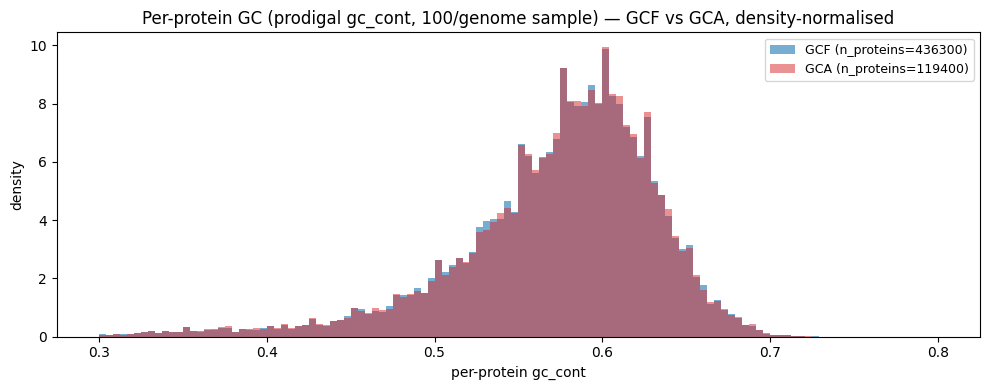

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
for t in TIER_ORDER:
    vals = per_prot.loc[per_prot["tier"] == t, "gc_cont"].dropna()
    if vals.empty:
        continue
    colour, alpha = TIER_COLOURS[t]
    ax.hist(vals, bins=120, range=(0.30, 0.80), alpha=alpha, color=colour,
            label=f"{t} (n_proteins={len(vals)})", density=True)
ax.set_xlabel("per-protein gc_cont")
ax.set_ylabel("density")
ax.set_title("Per-protein GC (prodigal gc_cont, 100/genome sample) — GCF vs GCA, density-normalised")
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()

## 3 · Per-genome weighted-mean protein GC (3-decimal)

The headline replacement for CheckM2's 2-decimal `GC_Content`. Weighted by per-protein DNA length, so a few short atypical genes don't drag the mean.

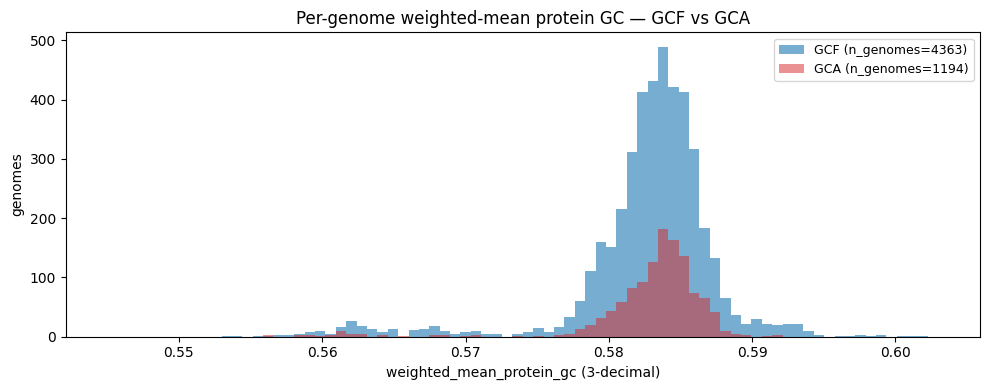

=== per-tier summary stats ===
      count    mean  median     std     min     max
tier                                               
GCF    4363  0.5826  0.5835  0.0055  0.5165  0.6016
GCA    1194  0.5829  0.5838  0.0044  0.5563  0.5919


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
all_vals = per_gene["weighted_mean_protein_gc"].dropna()
lo, hi = all_vals.quantile(0.001), all_vals.quantile(0.999)
lo, hi = round(lo - 0.005, 3), round(hi + 0.005, 3)
for t in TIER_ORDER:
    vals = per_gene.loc[per_gene["tier"] == t, "weighted_mean_protein_gc"].dropna()
    colour, alpha = TIER_COLOURS[t]
    ax.hist(vals, bins=80, range=(lo, hi), alpha=alpha, color=colour,
            label=f"{t} (n_genomes={len(vals)})")
ax.set_xlabel("weighted_mean_protein_gc (3-decimal)")
ax.set_ylabel("genomes")
ax.set_title("Per-genome weighted-mean protein GC — GCF vs GCA")
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()

print("=== per-tier summary stats ===")
print(
    per_gene.groupby("tier")["weighted_mean_protein_gc"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
    .reindex(TIER_ORDER)
)

## 4 · 3-decimal weighted-mean vs CheckM2's 2-decimal `GC_Content`

Sanity check: do the two numbers agree? Any systematic drift would suggest a bug in the parser or an unexpected difference between genome-wide GC (CheckM2) and protein-coding-region GC (our weighted mean over prodigal genes).

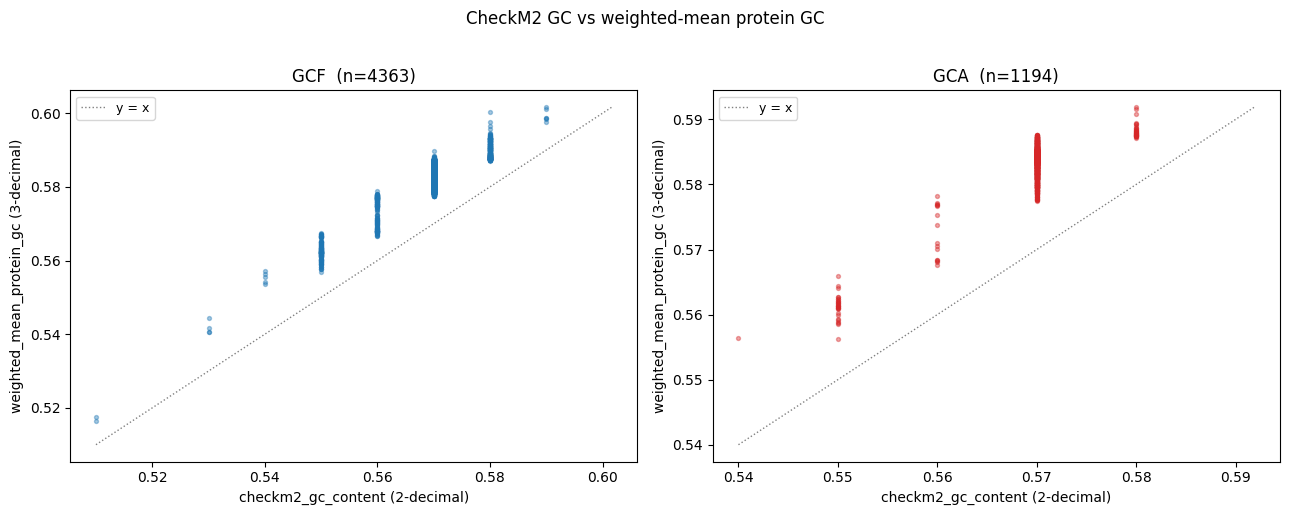

weighted_mean − checkm2_gc:  median +0.0134   IQR +0.0116 .. +0.0149
(protein-coding GC is typically ~0.005-0.02 above whole-genome GC for Klebsiella —
 the CDS regions are GC-richer than non-coding.)


In [4]:
joined = per_gene.merge(
    disc[["scoring_accession", "checkm2_gc_content"]],
    on="scoring_accession", how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, t in zip(axes, TIER_ORDER, strict=True):
    sub = joined[joined["tier"] == t].dropna(subset=["checkm2_gc_content", "weighted_mean_protein_gc"])
    colour, _ = TIER_COLOURS[t]
    ax.scatter(sub["checkm2_gc_content"], sub["weighted_mean_protein_gc"],
               s=8, alpha=0.4, color=colour)
    # y = x reference line
    lo = min(sub["checkm2_gc_content"].min(), sub["weighted_mean_protein_gc"].min())
    hi = max(sub["checkm2_gc_content"].max(), sub["weighted_mean_protein_gc"].max())
    ax.plot([lo, hi], [lo, hi], color="grey", lw=1, linestyle=":", label="y = x")
    ax.set_xlabel("checkm2_gc_content (2-decimal)")
    ax.set_ylabel("weighted_mean_protein_gc (3-decimal)")
    ax.set_title(f"{t}  (n={len(sub)})")
    ax.legend(loc="best", fontsize=9)
fig.suptitle("CheckM2 GC vs weighted-mean protein GC", y=1.02)
fig.tight_layout()
plt.show()

delta = (joined["weighted_mean_protein_gc"] - joined["checkm2_gc_content"]).dropna()
print(f"weighted_mean − checkm2_gc:  median {delta.median():+.4f}   IQR {delta.quantile(0.25):+.4f} .. {delta.quantile(0.75):+.4f}")
print("(protein-coding GC is typically ~0.005-0.02 above whole-genome GC for Klebsiella —\n the CDS regions are GC-richer than non-coding.)")

## 5 · Per-genome GC heterogeneity — outlier hunt

Within a single genome, protein GC should be tightly distributed (low `std_protein_gc`). A high `std_protein_gc` is a flag: chimeric assembly, contamination, or a genome that's genuinely mosaic (HGT-heavy). The GCA tier is where these are likeliest to hide — that's the population we want to weed out before merging into the LRA cohort.

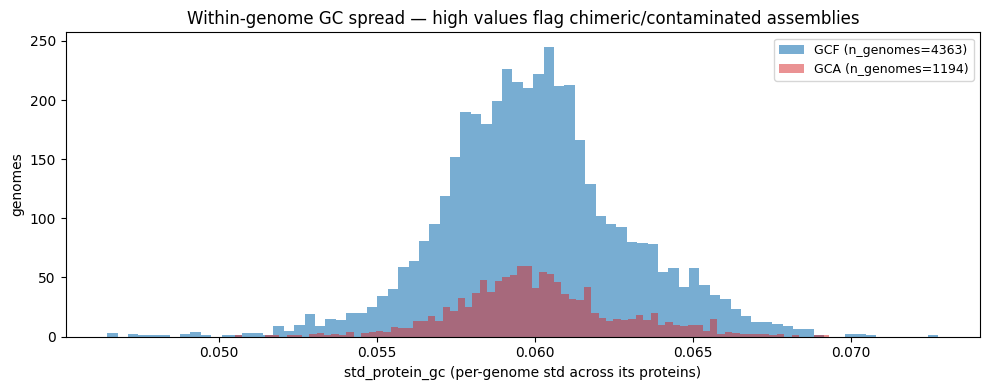

=== top 15 std_protein_gc (any tier) — candidates to inspect ===


,scoring_accession,tier,weighted_mean_protein_gc,std_protein_gc,n_proteins,checkm2_completeness,checkm2_contamination,is_norway,is_refseq,stale_refseq
0,GCF_024347795.1,GCF,0.578759,0.072772,5851,100.00,1.43,False,True,False
1,GCF_026614635.1,GCF,0.572395,0.070704,6031,100.00,1.32,False,False,False
2,GCF_026614535.1,GCF,0.572251,0.070407,6073,100.00,1.27,False,False,False
3,GCF_024347815.1,GCF,0.580000,0.070294,5828,100.00,1.32,False,True,False
4,GCF_041014805.1,GCF,0.579147,0.070082,5909,100.00,0.24,False,True,False
5,GCF_020525725.1,GCF,0.582204,0.069901,5658,100.00,0.61,False,True,False
6,GCA_948469915.1,GCA,0.573833,0.069300,11984,99.98,102.17,False,False,False
7,GCF_003571705.1,GCF,0.576996,0.069129,5625,100.00,0.37,False,True,False
8,GCA_025039755.1,GCA,0.576999,0.068904,5741,100.00,3.92,False,False,False
9,GCF_047783065.1,GCF,0.574557,0.068737,5722,100.00,0.34,False,True,False


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for t in TIER_ORDER:
    vals = per_gene.loc[per_gene["tier"] == t, "std_protein_gc"].dropna()
    colour, alpha = TIER_COLOURS[t]
    ax.hist(vals, bins=80, alpha=alpha, color=colour,
            label=f"{t} (n_genomes={len(vals)})")
ax.set_xlabel("std_protein_gc (per-genome std across its proteins)")
ax.set_ylabel("genomes")
ax.set_title("Within-genome GC spread — high values flag chimeric/contaminated assemblies")
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()

print("=== top 15 std_protein_gc (any tier) — candidates to inspect ===")
outliers = (
    per_gene.sort_values("std_protein_gc", ascending=False)
    .merge(disc[["scoring_accession", "checkm2_completeness", "checkm2_contamination",
                 "checkm2_genome_size", "is_norway", "is_refseq", "stale_refseq", "level"]],
           on="scoring_accession", how="left")
    .head(15)
)
display(outliers[[
    "scoring_accession", "tier", "weighted_mean_protein_gc", "std_protein_gc",
    "n_proteins", "checkm2_completeness", "checkm2_contamination",
    "is_norway", "is_refseq", "stale_refseq",
]])

## 6 · How to use these aggregates in the main notebook

`weighted_mean_protein_gc` is the 3-decimal replacement for `checkm2_gc_content`. To use it in `lra_quality_cutoffs.ipynb`, merge `per_gene` onto `disc` by `scoring_accession`:

```python
per_gene = pd.read_csv(PER_GENE_TSV, sep="\t", low_memory=False)
disc = disc.merge(
    per_gene[["scoring_accession", "weighted_mean_protein_gc", "std_protein_gc", "n_proteins"]],
    on="scoring_accession", how="left",
)
```

Then `overlay_hist("weighted_mean_protein_gc", bins=80, xlim=(0.55, 0.62))` gives the 3-decimal version of the GC plot.

If the std_protein_gc column proves informative for distinguishing real Klebsiella from contaminated outliers, it can also feed into the §7 acceptance rule in the main notebook.